## Importing Libraries

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
print(tf.config.list_physical_devices('GPU'))

C:\Users\LENOVO\anaconda3\envs\Tensorflow_Env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Loading Model

In [2]:
model  = tf.keras.models.load_model('trained_model.keras')

In [3]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

### Visualizaing Single Image of Test set

In [4]:
!pip install numpy==1.23.5
!pip install tensorflow==2.10.0
!pip install keras==2.10.0
!pip install matplotlib

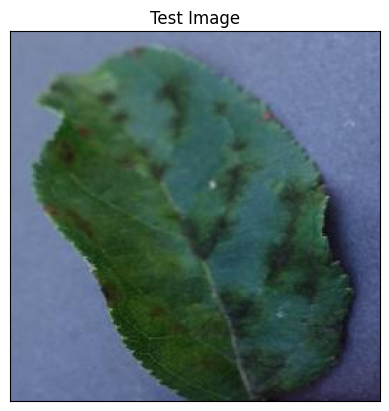

In [14]:
import cv2
import matplotlib.pyplot as plt

image_path = r"test/test/AppleScab2.JPG"

img = cv2.imread(image_path)

if img is None:
    print("❌ Image not found. Check path!")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title("Test Image")
    plt.xticks([])
    plt.yticks([])
    plt.show()

## Testing Model

In [15]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128, 128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr]) #Convert single image to a batch
print(input_arr.shape)

(1, 128, 128, 3)


In [16]:
prediction = model.predict(input_arr)
prediction,prediction.shape

1/1 [==============================] - 0s 163ms/step


(array([[9.99944091e-01, 3.52152097e-12, 2.93310103e-12, 5.56466148e-05,
         3.77301593e-11, 1.08504476e-10, 1.14809649e-14, 2.37955822e-10,
         8.23471133e-14, 6.07326526e-13, 4.60730527e-14, 1.18074180e-15,
         1.13166765e-16, 1.23361614e-17, 1.83892520e-16, 3.68623795e-12,
         2.44832790e-07, 1.55799007e-12, 1.16845024e-13, 8.84708864e-13,
         2.62317529e-11, 9.01778929e-11, 6.24271739e-13, 1.51312187e-14,
         4.41499288e-14, 1.27391451e-13, 4.28478528e-14, 3.01436709e-10,
         3.72543090e-16, 3.78432013e-13, 8.38093362e-14, 1.46751260e-08,
         1.20340478e-12, 2.13311722e-16, 2.53407965e-14, 7.99542192e-17,
         1.77752765e-15, 1.77145303e-14]], dtype=float32),
 (1, 38))

In [17]:
result_index = np.argmax(prediction)
result_index

0

In [18]:
class_name = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

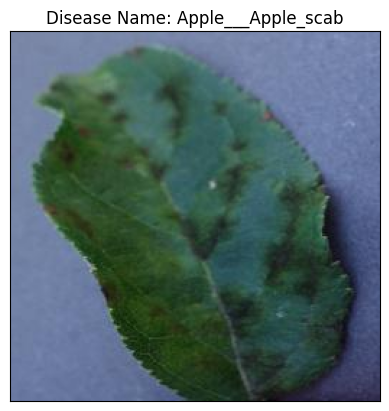

In [19]:
#Displaying Result of disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

In [20]:
model_prediction

'Apple___Apple_scab'